<a href="https://colab.research.google.com/github/Prab999/Machine-Learning-with-scikit-learn/blob/main/HumanActivity_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
#Load data
train_df = pd.read_csv('HumanActivity_train.csv')
test_df = pd.read_csv('HumanActivity_test.csv')

train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [3]:
#Separate Features
#dropping subject to not learn the person
X_train = train_df.drop(['Activity', 'subject'], axis=1)
y_train = train_df['Activity']

X_test = test_df.drop(['Activity', 'subject'], axis=1)
y_test = test_df['Activity']

#Encoding labels, only activity feature needs encoding
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

#Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Features Shape: {X_train_scaled.shape}")
print(f"Testing Features Shape: {X_test_scaled.shape}")
print(f"Activity Classes Mapped: {le.classes_}")

Training Features Shape: (7352, 561)
Testing Features Shape: (2947, 561)
Activity Classes Mapped: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


In [4]:
#Logistic Regression
import numpy as np
from sklearn.linear_model import LogisticRegression

logisticModel = LogisticRegression(penalty=None, max_iter=1000)
logisticModel.fit(X_train_scaled, y_train_encoded)
scoreTrain = logisticModel.score(X_train_scaled, y_train_encoded)
print('training accuracy', scoreTrain)
score = logisticModel.score(X_test_scaled, y_test_encoded)
print('test accuracy', score)

training accuracy 1.0
test accuracy 0.9426535459789617


In [6]:
#Model Tuning
from sklearn.model_selection import GridSearchCV

#tuning grid for regularization, 4 combinations
param_grid = {
    'penalty': ['l1', 'l2'],              #l1 better in each test
    'C': [1, 10, 100, 1000],              #1 previous best
    'solver': ['liblinear'],
    'max_iter': [1000]
}

# cv=5, 5-fold cross-validation
# return_train_score=True, to compare train vs validation later
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, return_train_score=True)

#Fit the grid search
print("Starting Grid Search...")
grid_search.fit(X_train_scaled, y_train_encoded)

#Extract the best model results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

#Evaluate the *best* model on the unseen test set
best_model = grid_search.best_estimator_

Starting Grid Search...
Best Parameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.943016135074016


Accuracy:  0.9596
Precision: 0.9610
Recall:    0.9596
F1-Score:  0.9594


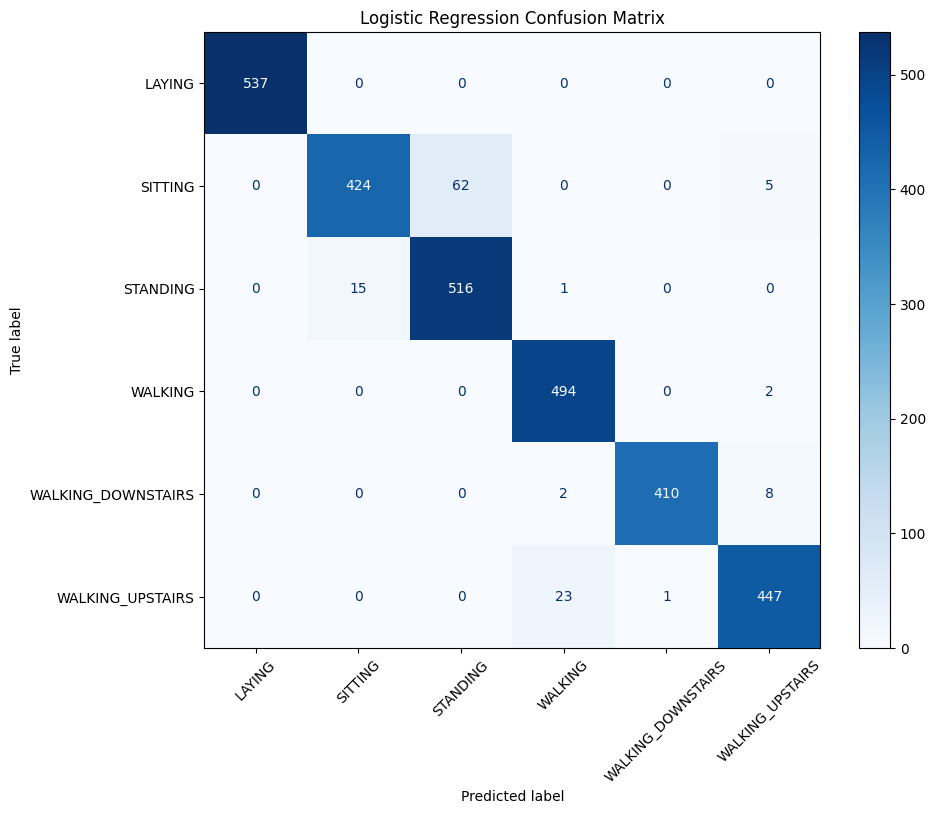

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# best model predict on unseen test data
y_pred = best_model.predict(X_test_scaled)

# 2. Calculate Metrics
print(f"Accuracy:  {accuracy_score(y_test_encoded, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_encoded, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_encoded, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test_encoded, y_pred, average='weighted'):.4f}")

# 3. Generate and Plot the Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Making plot larger
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [8]:
#KNN Model
import time
from sklearn.neighbors import KNeighborsClassifier

#kNN with default settings, 5 neighbors
knn_model = KNeighborsClassifier()

# Time the training phase
start_fit = time.time()
knn_model.fit(X_train_scaled, y_train_encoded)
print(f"k-NN Training Time: {time.time() - start_fit:.4f} seconds")

#testing/prediction
start_predict = time.time()
knn_score = knn_model.score(X_test_scaled, y_test_encoded)
print(f"k-NN Test Accuracy: {knn_score:.4f}")
print(f"k-NN Prediction Time: {time.time() - start_predict:.4f} seconds")

k-NN Training Time: 0.0600 seconds
k-NN Test Accuracy: 0.8836
k-NN Prediction Time: 2.4444 seconds


In [9]:
#Tuning, first test for best neighbor value:

# define tuning grid
param_grid_knn = {
    'n_neighbors': [11, 13, 15, 17, 19],  #11 prior best, so retune
    'weights': ['uniform', 'distance'] # Testing both weight methods from your notes
}

# GridSearchCV
# cv=5, 5-fold cross-validation
grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, return_train_score=True)

#Fit grid
print("Starting k-NN Grid Search...")
grid_search_knn.fit(X_train_scaled, y_train_encoded)

#Extract best model results
print("Best k-NN Parameters:", grid_search_knn.best_params_)
print("Best k-NN Cross-Validation Score:", grid_search_knn.best_score_)

# 5. Save best model
best_knn = grid_search_knn.best_estimator_

Starting k-NN Grid Search...
Best k-NN Parameters: {'n_neighbors': 17, 'weights': 'uniform'}
Best k-NN Cross-Validation Score: 0.8847943691412663


Logistic Regression ROC-AUC (OvR): 0.9959
k-NN ROC-AUC (OvR): 0.9903
----------------------------------------


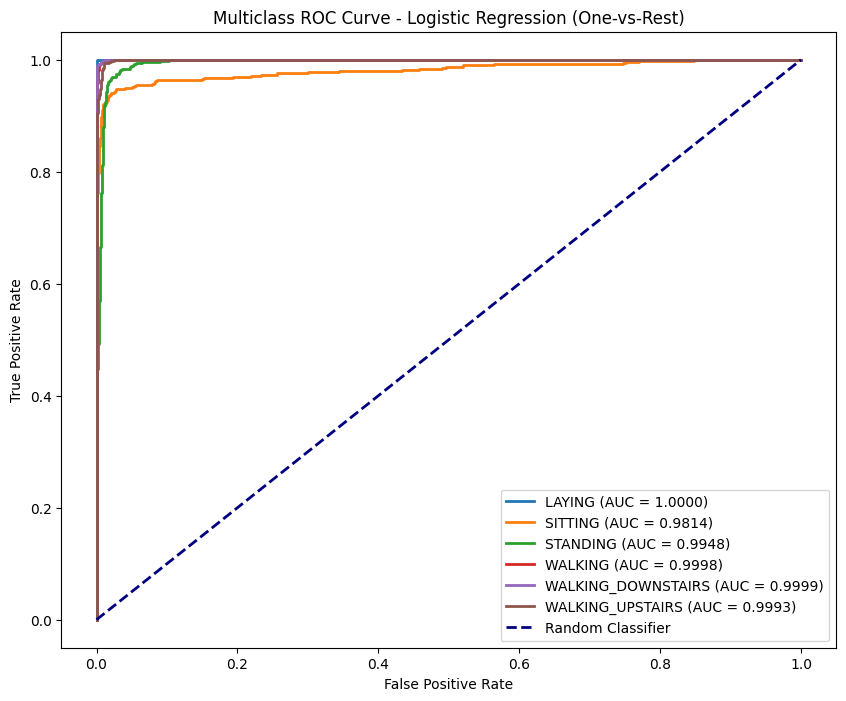

In [10]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# Binarize labels to allow for OvR calculations
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test_encoded)

#probability predictions instead of class labels
y_prob_log = best_model.predict_proba(X_test_scaled)
y_prob_knn = best_knn.predict_proba(X_test_scaled)

# 3. CalculateROC-AUC Score
auc_score_log = roc_auc_score(y_test_encoded, y_prob_log, multi_class='ovr')
auc_score_knn = roc_auc_score(y_test_encoded, y_prob_knn, multi_class='ovr')

print(f"Logistic Regression ROC-AUC (OvR): {auc_score_log:.4f}")
print(f"k-NN ROC-AUC (OvR): {auc_score_knn:.4f}")
print("-" * 40)

# 4. Plot Multiclass ROC curve
fig, ax = plt.subplots(figsize=(10, 8))

# Loop through each of the 6 classes to plot their specific curve
for i in range(len(le.classes_)):
    # Calculate False Positive Rate and True Positive Rate for class 'i'
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_log[:, i])
    roc_auc = auc(fpr, tpr)

    # Plot the line for class 'i'
    ax.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc:.4f})')

# Plot the baseline
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Multiclass ROC Curve - Logistic Regression (One-vs-Rest)')
ax.legend(loc="lower right")
plt.show()

Accuracy:  0.8904
Precision: 0.9003
Recall:    0.8904
F1-Score:  0.8892


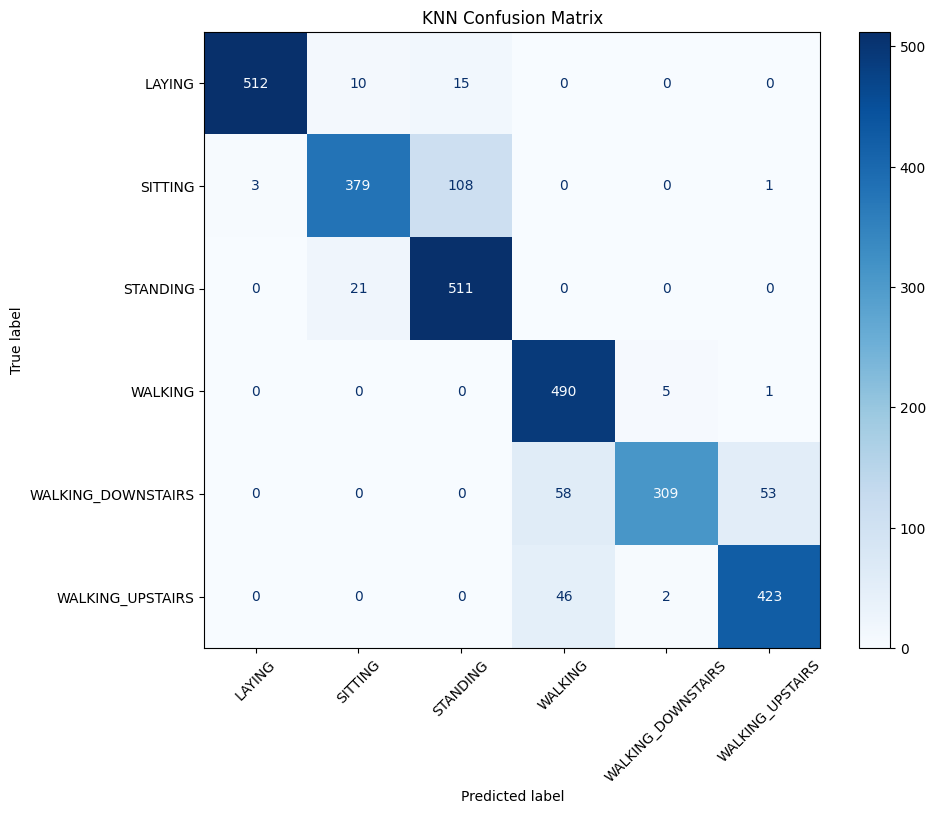

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# best model predict on the unseen test data
y_pred = best_knn.predict(X_test_scaled)

# Calculate Metrics
print(f"Accuracy:  {accuracy_score(y_test_encoded, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_encoded, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_encoded, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test_encoded, y_pred, average='weighted'):.4f}")

# Generate and Plot the Confusion Matrix
cm = confusion_matrix(y_test_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Making plot larger
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
plt.title("KNN Confusion Matrix")
plt.show()

Variance explained by 2 Principal Components: 57.36%


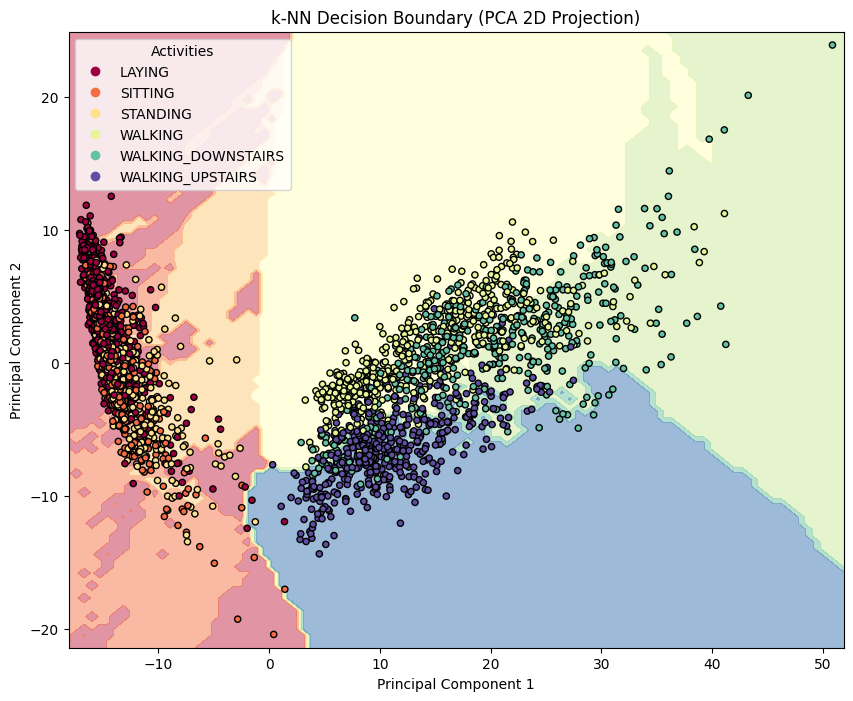

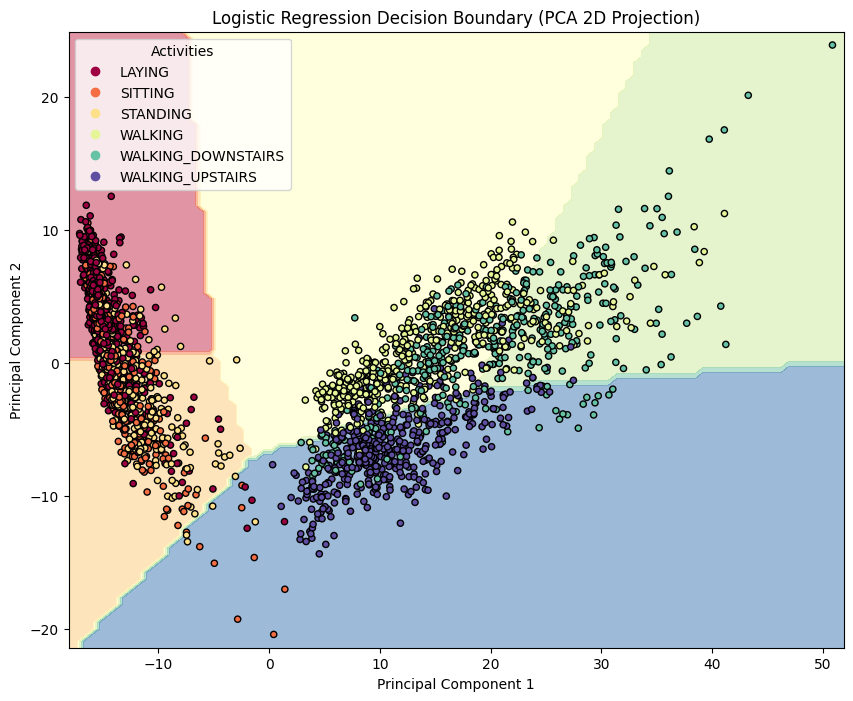

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import DecisionBoundaryDisplay

#  Reduce dimensionality to 2D for visualization purposes
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print variance explained to understand how much information was lost
explained_variance = pca.explained_variance_ratio_.sum() * 100
print(f"Variance explained by 2 Principal Components: {explained_variance:.2f}%")

# Re-train models strictly on the 2D data
# Using previously found best parameters
knn_2d = KNeighborsClassifier(n_neighbors=17, weights='uniform')
knn_2d.fit(X_train_pca, y_train_encoded)

log_2d = LogisticRegression(penalty='l1', C=1, solver='liblinear', max_iter=1000)
log_2d.fit(X_train_pca, y_train_encoded)

# Create a plotting function
def plot_decision_boundary(model, X_pca, y_encoded, title):
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the decision boundaries
    disp = DecisionBoundaryDisplay.from_estimator(
        model,
        X_pca,
        response_method="predict",
        cmap=plt.cm.Spectral,
        alpha=0.5,
        ax=ax
    )

    # Scatter plot the actual test data points on top
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=y_encoded,
        cmap=plt.cm.Spectral,
        edgecolors='k',
        s=20
    )

    # Add a legend using previously fitted LabelEncoder
    handles, _ = scatter.legend_elements()
    ax.legend(handles, le.classes_, title="Activities", loc="best")

    ax.set_title(title)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    plt.show()

# Generate the plots using the unseen test data
plot_decision_boundary(knn_2d, X_test_pca, y_test_encoded, "k-NN Decision Boundary (PCA 2D Projection)")
plot_decision_boundary(log_2d, X_test_pca, y_test_encoded, "Logistic Regression Decision Boundary (PCA 2D Projection)")